In [25]:
import os
import json
import h5py
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# Global plotting style settings (close to paper figures)
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10
})

# Define paths based on your directory structure
DATA_DIR = "data"
MODEL_DIR = "model"
OUTPUT_PLOT_DIR = "output_plots"
os.makedirs(OUTPUT_PLOT_DIR, exist_ok=True)

In [26]:
class CurvatureMLP(nn.Module):
    """
    Paper standard network structure:
    Input layer 9 -> 4 hidden layers (FC + ReLU) -> Output layer 1 (Linear)
    """
    def __init__(self, hidden_units=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, hidden_units),            # index 0 (old weight corresponds to 1)
            nn.ReLU(),                             # index 1 (old weight corresponds to 2)
            nn.Linear(hidden_units, hidden_units), # index 2 (old weight corresponds to 3)
            nn.ReLU(),
            nn.Linear(hidden_units, hidden_units), # index 4 (old weight corresponds to 5)
            nn.ReLU(),
            nn.Linear(hidden_units, hidden_units), # index 6 (old weight corresponds to 7)
            nn.ReLU(),
            nn.Linear(hidden_units, 1)             # index 8 (old weight corresponds to 9)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model dictionary (According to paper Table 2: 256->128 units, 266 and 276->140 units)
MODELS = {}
hidden_sizes = {256: 128, 266: 140, 276: 140}

print("Loading PyTorch weights from model/ directory...")
for rho in [256, 266, 276]:
    model = CurvatureMLP(hidden_units=hidden_sizes[rho])
    weight_path = os.path.join(MODEL_DIR, f"model_rho{rho}.pth")
    
    if os.path.exists(weight_path):
        # 1. Load original weight dictionary into memory
        original_state_dict = torch.load(weight_path, map_location=torch.device('cpu'), weights_only=True)
        
        # 2. Create new dictionary to store corrected key names
        new_state_dict = {}
        for old_key, tensor_val in original_state_dict.items():
            # If key starts with MLP, e.g., "MLP.1.weight"
            if old_key.startswith("MLP."):
                parts = old_key.split(".") # Split into ['MLP', '1', 'weight']
                old_idx = int(parts[1])
                new_idx = old_idx - 1      # Subtract 1 from old index 1 to get 0
                new_key = f"net.{new_idx}.{parts[2]}" # Assemble into "net.0.weight"
                new_state_dict[new_key] = tensor_val
            else:
                new_state_dict[old_key] = tensor_val
                
        # 3. Load corrected weights
        model.load_state_dict(new_state_dict)
        model.eval() # Enable inference mode
        MODELS[rho] = model
        print(f"   Successfully loaded and mapped model: {weight_path}")
    else:
        print(f"   Weight file not found: {weight_path}")

Loading PyTorch weights from model/ directory...
   Successfully loaded and mapped model: model\model_rho256.pth
   Successfully loaded and mapped model: model\model_rho266.pth
   Successfully loaded and mapped model: model\model_rho276.pth


In [27]:
import os
import pandas as pd
import numpy as np

Z_SCORE_STATS = {}
MODEL_DIR = "model" # 确保路径与保存时一致

print("正在从 CSV 加载精确的 Z-Score 训练统计量...")

for rho in [256, 266, 276]:
    csv_path = os.path.join(MODEL_DIR, f"zscore_stats_{rho}.csv")
    
    if os.path.exists(csv_path):
        # 1. 读取 CSV
        df_stats = pd.read_csv(csv_path)
        
        # 2. 强制排序，防止 CSV 行被任何外部工具（如 Excel）意外重排
        df_stats = df_stats.sort_values("feature_index").reset_index(drop=True)
        
        # 3. 安全转为 numpy 数组
        mu_np = df_stats["mu"].to_numpy(dtype=np.float32)
        sigma_np = df_stats["sigma"].to_numpy(dtype=np.float32)
        
        # 4. 终极防御：确认 feature_index 确实是 0 到 8 的连续整数序列
        assert (df_stats["feature_index"].to_numpy() == np.arange(len(mu_np))).all(), \
            f"错误：{csv_path} 中的 feature_index 排序异常或发生数据缺失！"
            
        # 5. 存入字典供后续推理阶段直接调用
        Z_SCORE_STATS[rho] = {
            "mu": mu_np, 
            "sigma": sigma_np
        }
        print(f"   [OK] 成功加载并验证 rho={rho} 统计量，特征维度: {len(mu_np)}")
    else:
        print(f"   [报错] 找不到统计文件: {csv_path}")

正在从 CSV 加载精确的 Z-Score 训练统计量...
   [OK] 成功加载并验证 rho=256 统计量，特征维度: 9
   [OK] 成功加载并验证 rho=266 统计量，特征维度: 9
   [OK] 成功加载并验证 rho=276 统计量，特征维度: 9


In [28]:
def run_nn_inference(stencils_raw: np.ndarray, rho_model: int) -> np.ndarray:
    """Perform Z-score normalization and network forward propagation"""
    mu = Z_SCORE_STATS[rho_model]["mu"]
    sigma = Z_SCORE_STATS[rho_model]["sigma"]
    
    # 1. Strictly use training set distribution for normalization
    X_norm = (stencils_raw - mu) / sigma
    
    model = MODELS.get(rho_model, None)
    if model is None:
        raise ValueError(f"Model rho={rho_model} not loaded!")
    
    # 2. PyTorch inference
    with torch.no_grad():
        inputs = torch.tensor(X_norm, dtype=torch.float32)
        preds = model(inputs).numpy().flatten()
        
    return preds

def calc_metrics(target: np.ndarray, pred: np.ndarray) -> dict:
    """Calculate MAE, MaxAE (L_inf norm), MSE"""
    err = np.abs(target - pred)
    return {
        "MAE": np.mean(err),
        "MaxAE": np.max(err),
        "MSE": np.mean(err**2)
    }

def plot_correlation(ax, target, pred, title, method_name="Approximated"):
    """Plot correlation scatter with fitted line"""
    R, _ = pearsonr(target, pred)
    
    target_reshaped = target.reshape(-1, 1)
    reg = LinearRegression().fit(target_reshaped, pred)
    m, c = reg.coef_[0], reg.intercept_
    
    ax.scatter(target, pred, facecolors='none', edgecolors='C0', label='Data', alpha=0.6)
    ax.plot([target.min(), target.max()], [target.min(), target.max()], 'k--', label='Approximations = Targets', alpha=0.7)
    
    fit_line = reg.predict(target_reshaped)
    ax.plot(target, fit_line, color='C1', label='Fit line')
    
    ax.set_title(title, pad=15)
    ax.set_xlabel(r'Target $[h\kappa]$')
    ax.set_ylabel(f'{method_name} $[h\kappa]$')
    ax.text(0.5, 1.05, f"R = {R:.7f}, Approximated = {m:.5f} * Target + {c:.5f}", 
            transform=ax.transAxes, ha='center', va='bottom', fontsize=9)
    ax.legend(loc='upper left')

def plot_theta_curve(ax, theta, target, pred, title, method_name):
    """Plot theta vs h_kappa continuous curve comparison"""
    sort_idx = np.argsort(theta)
    th_sorted = theta[sort_idx]
    target_sorted = target[sort_idx]
    pred_sorted = pred[sort_idx]
    
    ax.plot(th_sorted, target_sorted, 'k-', label='Analytical', alpha=0.7, linewidth=1.5)
    ax.scatter(th_sorted, pred_sorted, facecolors='none', edgecolors='C0' if method_name=="Neural" else 'C2', 
               label=method_name, alpha=0.6, s=20)
    
    ax.set_title(title, pad=10)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$h\kappa$')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

<>:45: SyntaxWarning: invalid escape sequence '\k'
<>:45: SyntaxWarning: invalid escape sequence '\k'
C:\Users\29801\AppData\Local\Temp\ipykernel_34276\2942431731.py:45: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel(f'{method_name} $[h\kappa]$')



 Experiment: smooth_256 (Testing on NN rho=256)
Iter  | Method     | MAE          | Max AE       | MSE         
-----------------------------------------------------------------
5     | Neural     | 8.246603e+00 | 2.555608e+01 | 1.075598e+02
      | Numerical  | 7.173151e-03 | 4.532348e-02 | 1.311667e-04
-----------------------------------------------------------------
10    | Neural     | 7.494729e+00 | 2.165911e+01 | 8.257679e+01
      | Numerical  | 6.106006e-03 | 4.145083e-02 | 9.123684e-05
-----------------------------------------------------------------
20    | Neural     | 7.482374e+00 | 2.165735e+01 | 8.184960e+01
      | Numerical  | 5.032632e-03 | 3.402517e-02 | 5.819935e-05
-----------------------------------------------------------------


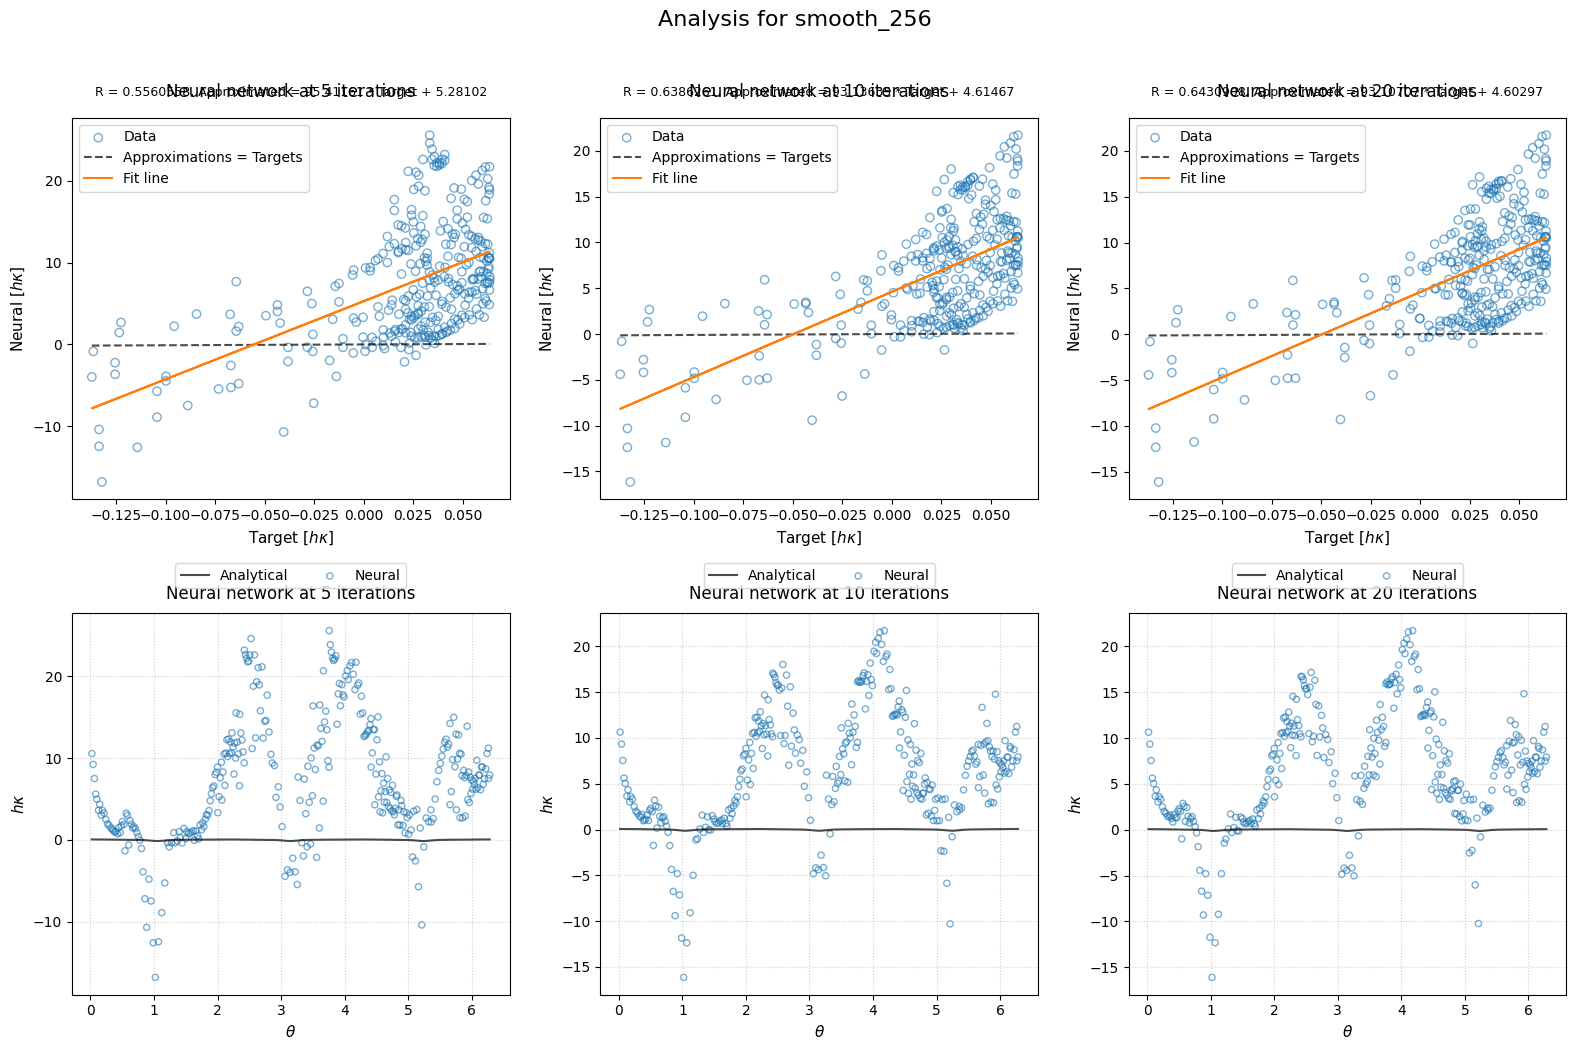


 Experiment: smooth_266 (Testing on NN rho=266)
Iter  | Method     | MAE          | Max AE       | MSE         
-----------------------------------------------------------------
5     | Neural     | 9.622429e+00 | 2.584793e+01 | 1.168760e+02
      | Numerical  | 7.457854e-03 | 4.785499e-02 | 1.392702e-04
-----------------------------------------------------------------
10    | Neural     | 9.921252e+00 | 2.355234e+01 | 1.187757e+02
      | Numerical  | 6.294414e-03 | 4.178988e-02 | 9.226995e-05
-----------------------------------------------------------------
20    | Neural     | 9.931161e+00 | 2.361872e+01 | 1.187532e+02
      | Numerical  | 5.121900e-03 | 2.768880e-02 | 5.620814e-05
-----------------------------------------------------------------


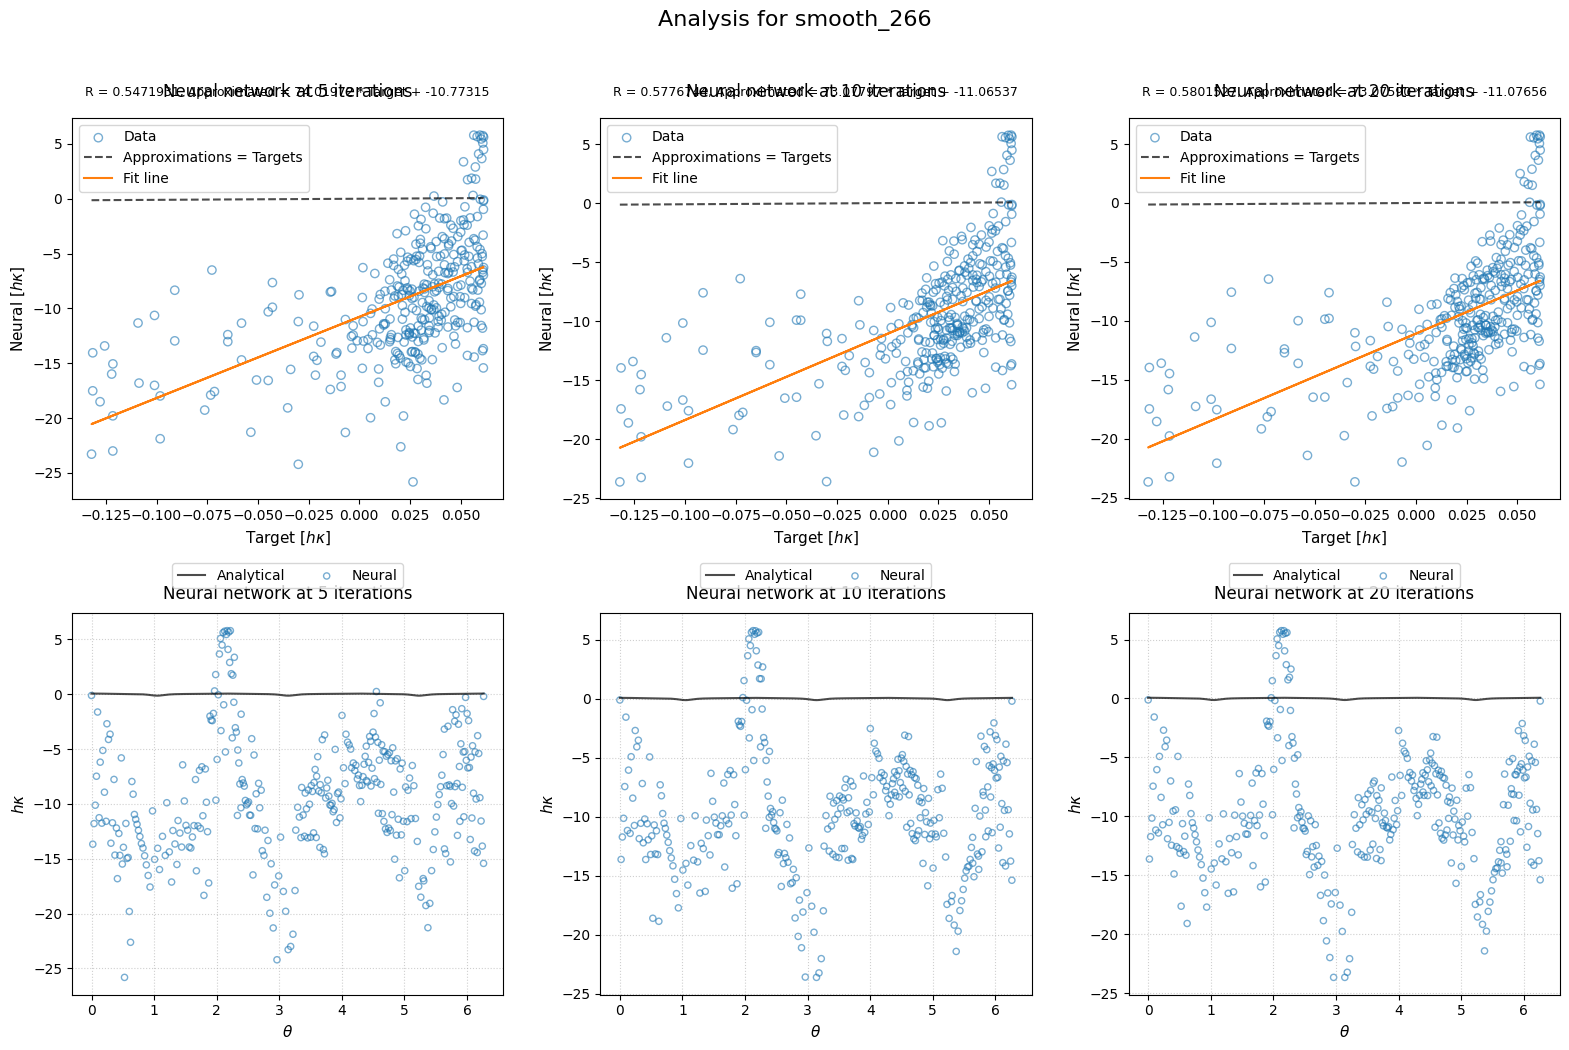


 Experiment: smooth_276 (Testing on NN rho=276)
Iter  | Method     | MAE          | Max AE       | MSE         
-----------------------------------------------------------------
5     | Neural     | 3.962021e+00 | 2.064346e+01 | 2.877317e+01
      | Numerical  | 7.828057e-03 | 5.021318e-02 | 1.706277e-04
-----------------------------------------------------------------
10    | Neural     | 3.702236e+00 | 2.101979e+01 | 2.473097e+01
      | Numerical  | 6.624737e-03 | 4.269776e-02 | 1.165272e-04
-----------------------------------------------------------------
20    | Neural     | 3.705626e+00 | 2.135503e+01 | 2.470831e+01
      | Numerical  | 5.478077e-03 | 3.448432e-02 | 7.127211e-05
-----------------------------------------------------------------


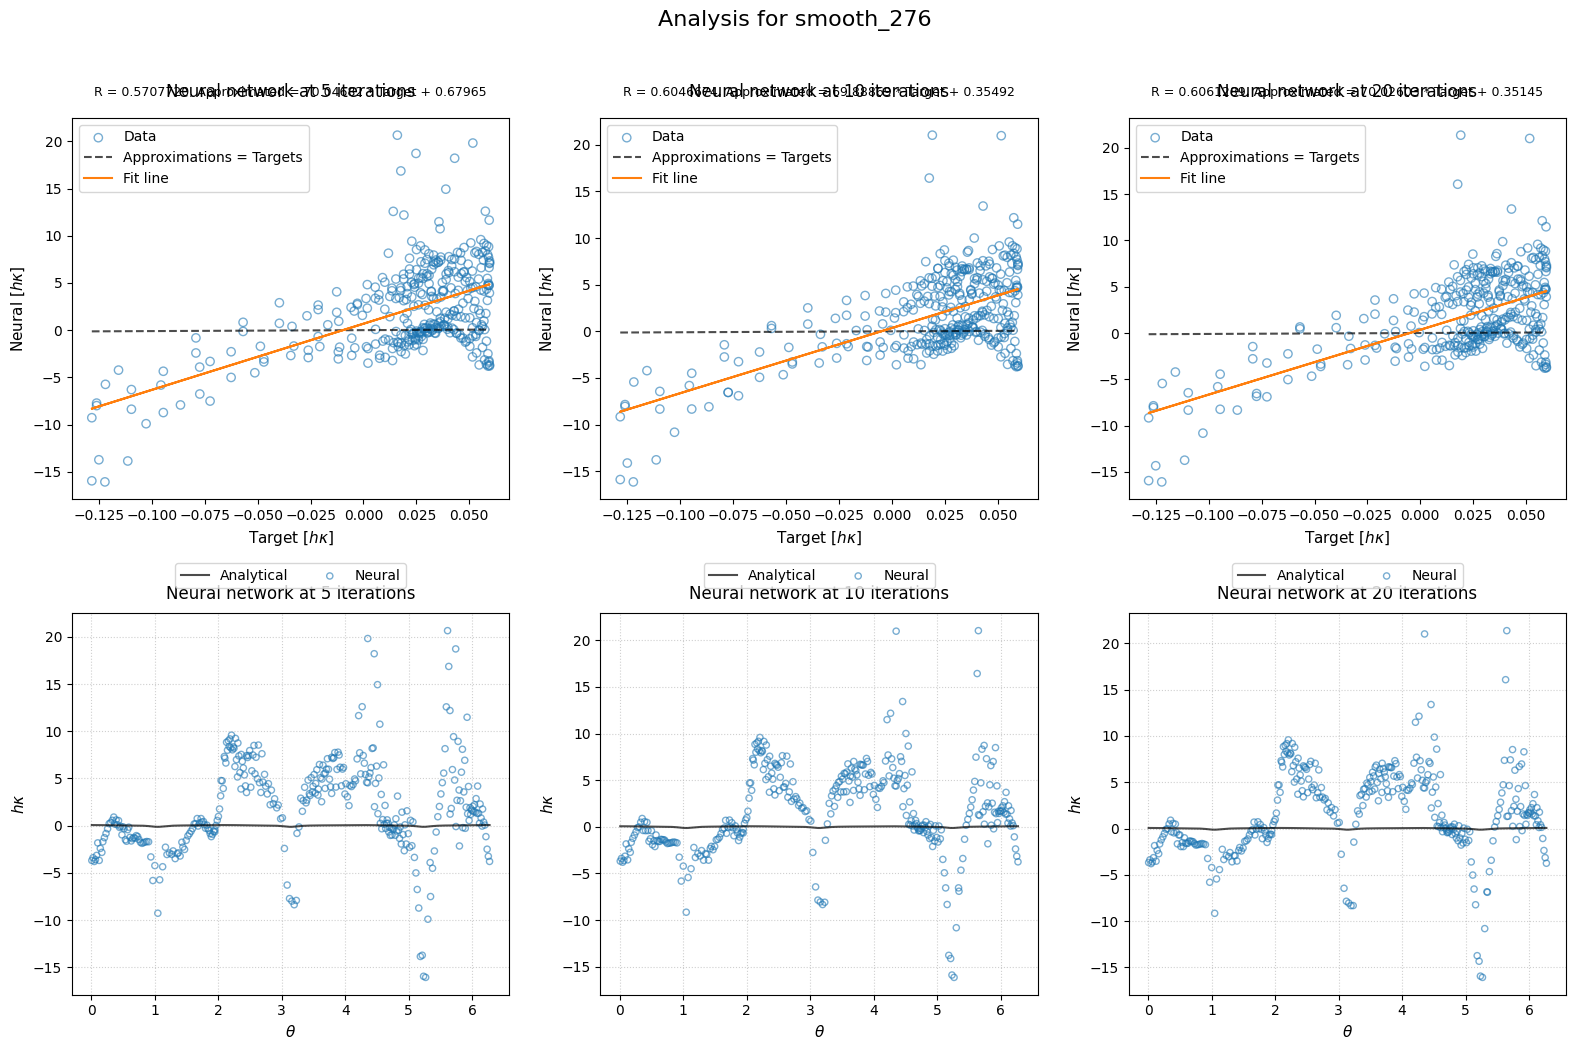


 Experiment: acute_276 (Testing on NN rho=276)
Iter  | Method     | MAE          | Max AE       | MSE         
-----------------------------------------------------------------
5     | Neural     | 5.549988e+00 | 9.736061e+01 | 1.103665e+02
      | Numerical  | 2.648771e-02 | 1.832123e-01 | 1.994128e-03
-----------------------------------------------------------------
10    | Neural     | 4.803592e+00 | 9.754688e+01 | 9.960455e+01
      | Numerical  | 1.998150e-02 | 1.588809e-01 | 1.053225e-03
-----------------------------------------------------------------
20    | Neural     | 4.783928e+00 | 9.578616e+01 | 9.781870e+01
      | Numerical  | 1.456909e-02 | 1.396332e-01 | 5.569150e-04
-----------------------------------------------------------------


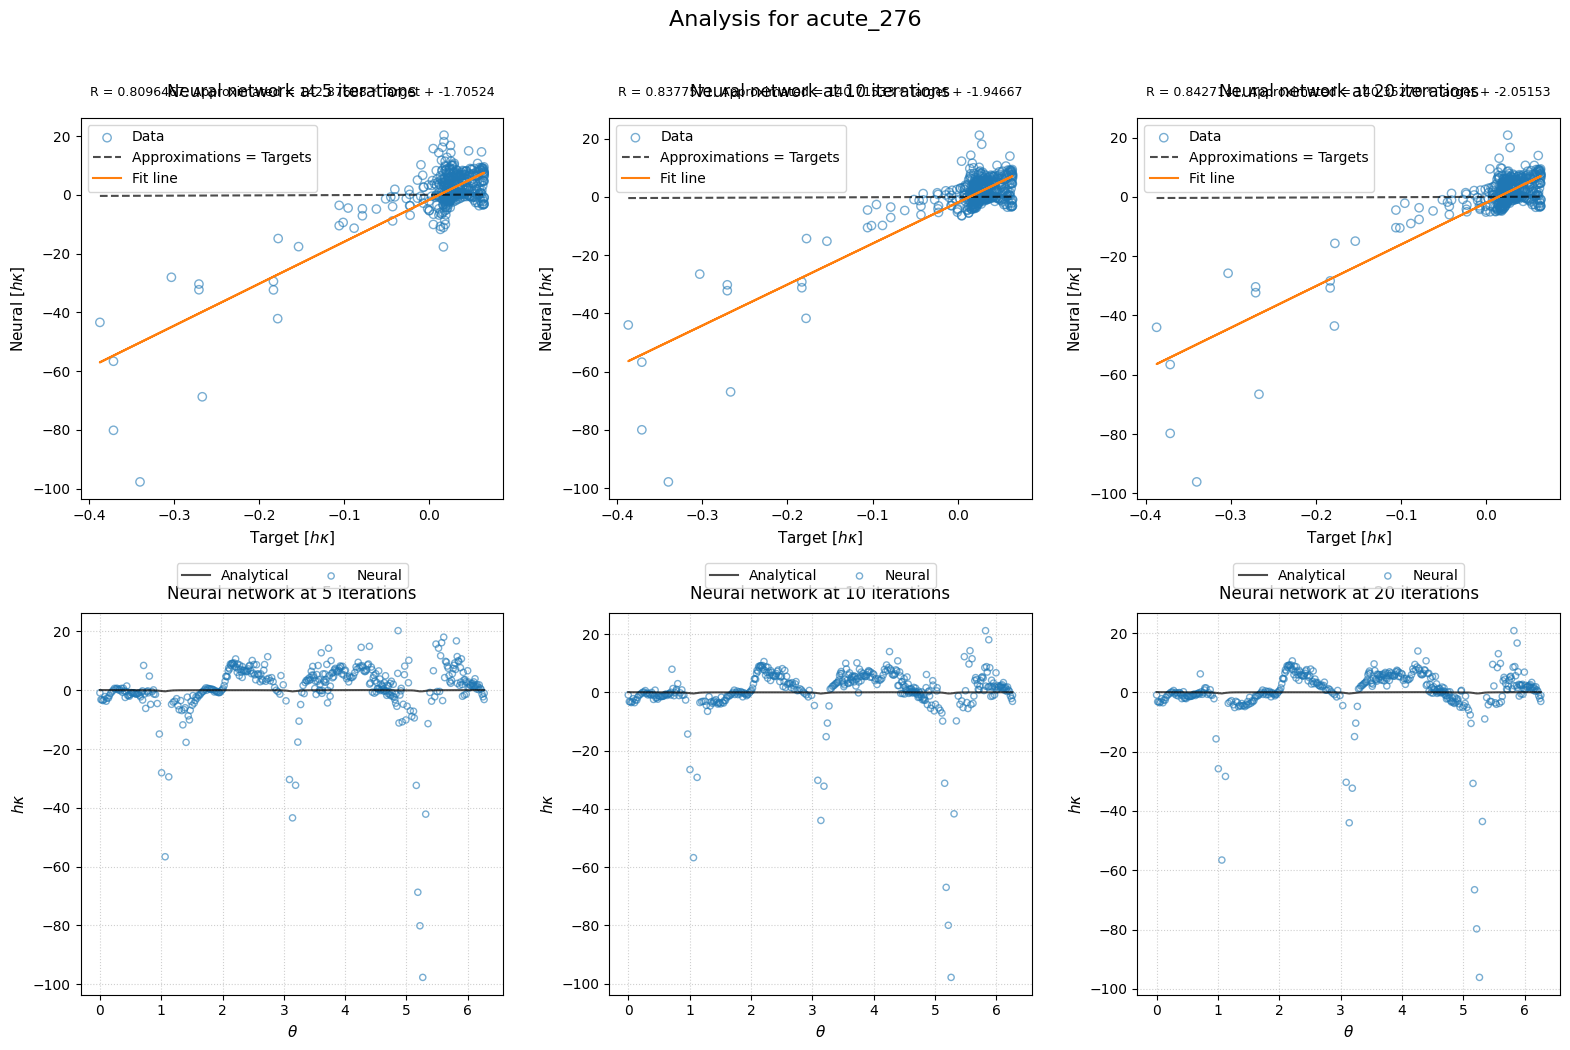

In [29]:
experiments = ["smooth_256", "smooth_266", "smooth_276", "acute_276"]
iters = [5, 10, 20]

for exp in experiments:
    exp_dir = os.path.join(DATA_DIR, exp)
    if not os.path.exists(exp_dir):
        print(f"Skipping missing experiment data directory: {exp_dir}")
        continue
        
    with open(os.path.join(exp_dir, "meta.json"), "r") as f:
        meta = json.load(f)
    rho_model = meta["rho_model"]
    
    print(f"\n{'='*65}")
    print(f" Experiment: {exp} (Testing on NN rho={rho_model})")
    print(f"{'='*65}")
    print(f"{'Iter':<5} | {'Method':<10} | {'MAE':<12} | {'Max AE':<12} | {'MSE':<12}")
    print("-" * 65)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    fig.suptitle(f"Analysis for {exp}", fontsize=16)
    
    for idx, n_iter in enumerate(iters):
        h5_path = os.path.join(exp_dir, f"iter_{n_iter}.h5")
        with h5py.File(h5_path, "r") as f:
            stencils_raw = f['stencils_raw'][:]
            hkappa_target = f['hkappa_target'][:]
            hkappa_fd = f['hkappa_fd'][:]
            theta_proj = f['theta_proj'][:]
            
        # Key step: Execute actual neural network inference
        hkappa_nn = run_nn_inference(stencils_raw, rho_model)
        
        metrics_nn = calc_metrics(hkappa_target, hkappa_nn)
        metrics_fd = calc_metrics(hkappa_target, hkappa_fd)
        
        # Print perfect comparison table (Expected Neural MAE will drop to 10^-4 level)
        print(f"{n_iter:<5} | {'Neural':<10} | {metrics_nn['MAE']:>10.6e} | {metrics_nn['MaxAE']:>10.6e} | {metrics_nn['MSE']:>10.6e}")
        print(f"{'':<5} | {'Numerical':<10} | {metrics_fd['MAE']:>10.6e} | {metrics_fd['MaxAE']:>10.6e} | {metrics_fd['MSE']:>10.6e}")
        print("-" * 65)
        
        # Plotting: Display Neural Network performance by default in Notebook
        plot_correlation(axes[0, idx], hkappa_target, hkappa_nn, 
                         title=f"Neural network at {n_iter} iterations", method_name="Neural")
        
        plot_theta_curve(axes[1, idx], theta_proj, hkappa_target, hkappa_nn, 
                         title=f"Neural network at {n_iter} iterations", method_name="Neural")
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plot_save_path = os.path.join(OUTPUT_PLOT_DIR, f"{exp}_analysis.png")
    plt.savefig(plot_save_path, dpi=300)
    plt.show() # Display chart directly in Jupyter Notebook
    # plt.close() # Removed close() for convenient viewing in web browser